Dimensions: FrozenMappingWarningOnValuesAccess({'time': 660, 'bnds': 2, 'lat': 180, 'lon': 360})

--- ALL Available Variables ---
['tmnth_bnds', 'count_ncruise', 'fco2_count_nobs', 'fco2_ave_weighted', 'fco2_ave_unwtd', 'fco2_min_unwtd', 'fco2_max_unwtd', 'fco2_std_weighted', 'fco2_std_unwtd', 'sst_count_nobs', 'sst_ave_weighted', 'sst_ave_unwtd', 'sst_min_unwtd', 'sst_max_unwtd', 'sst_std_weighted', 'sst_std_unwtd', 'salinity_count_nobs', 'salinity_ave_weighted', 'salinity_ave_unwtd', 'salinity_min_unwtd', 'salinity_max_unwtd', 'salinity_std_weighted', 'salinity_std_unwtd', 'lat_offset_unwtd', 'lon_offset_unwtd']

✅ Found variable: 'fco2_ave_unwtd'
🎨 Plotting data for 2024-12 (Most recent)...


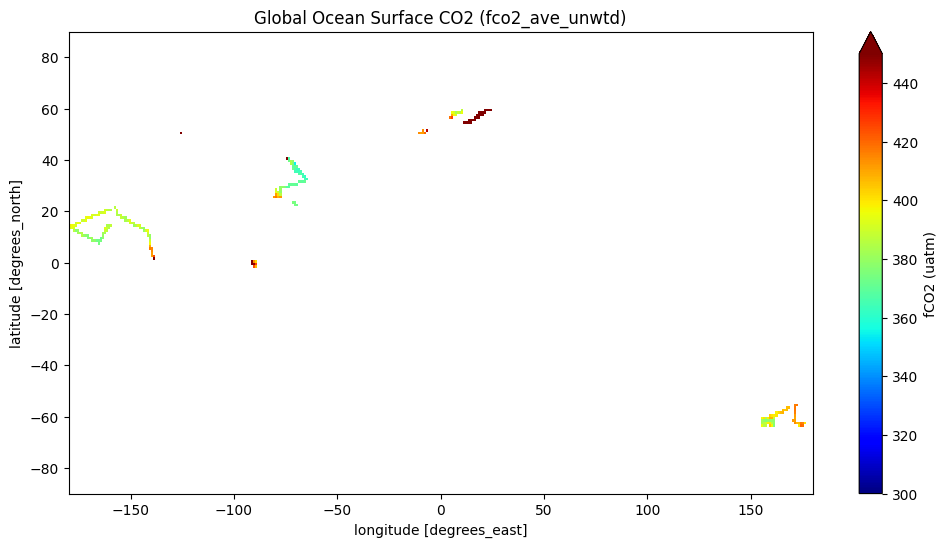

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Load & Rename
data_path = Path("../data/01_raw/SOCATv2025_tracks_gridded_monthly.nc")
ds = xr.open_dataset(data_path, chunks={"tmnth": 10})
ds = ds.rename({"tmnth": "time", "ylat": "lat", "xlon": "lon"})

# 2. Print ALL variables (No filter)
print(f"Dimensions: {ds.dims}")
print("\n--- ALL Available Variables ---")
print(list(ds.data_vars))

# 3. Auto-detect the CO2 variable
# We look for common SOCAT names (weighted or unweighted average)
possible_names = ['fco2_ave_unwtd', 'fco2_ave_weighted', 'fCO2_rec_mean', 'OceCO2']
target_var = None

for name in possible_names:
    if name in ds:
        target_var = name
        break

# 4. Plot
if target_var:
    print(f"\n✅ Found variable: '{target_var}'")
    print(f"🎨 Plotting data for {str(ds.time.values[-1])[:7]} (Most recent)...")
    
    plt.figure(figsize=(12, 6))
    ds[target_var].isel(time=-1).plot( # Plotting the LAST month (Recent data)
        cmap="jet", 
        vmin=300, vmax=450,
        cbar_kwargs={'label': 'fCO2 (uatm)'}
    )
    plt.title(f"Global Ocean Surface CO2 ({target_var})")
    plt.show()
else:
    print("\n❌ Still couldn't auto-detect. Please paste the list printed above!")

In [4]:
# Check for Physics Variables
print("--- Searching for Drivers ---")
for var in ds.data_vars:
    # Search for Temperature (sst) and Salinity (sal)
    if any(x in var.lower() for x in ['sst', 'temp', 'sal']):
        print(f"found: {var}")

--- Searching for Drivers ---
found: sst_count_nobs
found: sst_ave_weighted
found: sst_ave_unwtd
found: sst_min_unwtd
found: sst_max_unwtd
found: sst_std_weighted
found: sst_std_unwtd
found: salinity_count_nobs
found: salinity_ave_weighted
found: salinity_ave_unwtd
found: salinity_min_unwtd
found: salinity_max_unwtd
found: salinity_std_weighted
found: salinity_std_unwtd
